---
title: "Lecture 8: Conditioning, Bayes' Rule"
author: "Jamie Haddock"
format:
    revealjs:
        output-file: Lecture8_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: katex
        slide-level: 3
    html:
        code-fold: true
        embed-resources: true
        output-file: Lecture8
        code-links:
          - text: "Open in Colab"
            href: "https://colab.research.google.com/github/jamiehadd/Math-151-Probability/blob/main/08_conditioning-bayes-rule.ipynb"
            icon: "laptop"
    pdf:
        documentclass: article
        toc: true
        number-sections: true
        output-file: Lecture8
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: python3
colab:
  gh-user: "jamiehadd"
  gh-repo: "Math-151-Probability"
filters:
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats, integrate

rng = np.random.default_rng(151)
plt.rcParams["figure.figsize"] = (6, 4)

# Conditioning

## Conditioning a Random Variable on an Event

We already know how to condition one *event* on another. Now we condition a
random variable $X$ on an event $A$ (with $P(A) > 0$): we simply restrict
attention to the outcomes in $A$, and renormalize.

::: {.callout-note}
## Definition: conditional PMF / PDF given an event

**Discrete.** For $P(A) > 0$,
$$
p_{X\mid A}(x) \;=\; P(X = x \mid A) \;=\; \frac{P(\{X = x\} \cap A)}{P(A)}.
$$

**Continuous.** For $P(A) > 0$,
$$
f_{X\mid A}(x) \;=\; \lim_{\delta \to 0} \frac{P(x \le X \le x + \delta \mid A)}{\delta},
$$
which, whenever $A$ is expressed in terms of $X$ (e.g. $A = \{X \in S\}$), works
out to
$$
f_{X\mid A}(x) = \begin{cases} \dfrac{f_X(x)}{P(A)}, & x \in S,\\[4pt] 0, & \text{otherwise.}\end{cases}
$$
:::

. . .

Either way, conditioning does two things to the picture of $f_X$: it **zeroes
out** the mass/density outside $A$, and **rescales** what remains so it once
again integrates (or sums) to $1$.

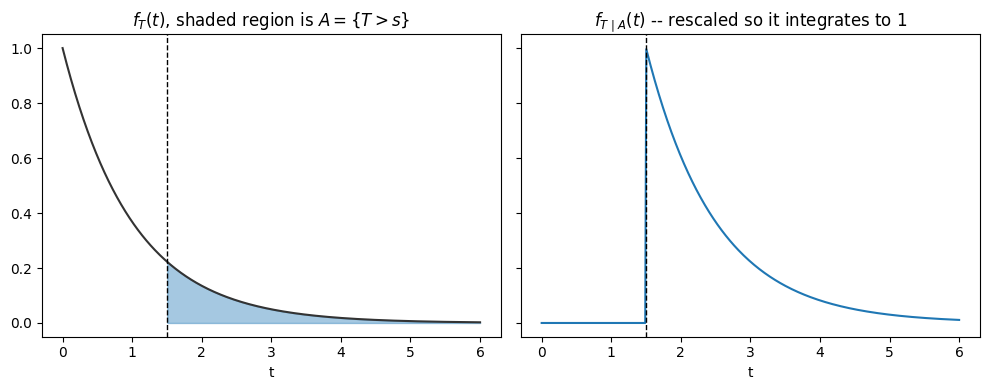

P(A) = P(T > s) = 0.2231
check: integral of f_T|A = 1.0000


In [2]:
# "meet image!" -- picture the effect of conditioning on an event
lam = 1.0
t = np.linspace(0, 6, 400)
f = lam * np.exp(-lam * t)

s = 1.5
mask = t >= s
PA = np.exp(-lam * s)  # P(T > s)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].plot(t, f, color="0.2")
axes[0].fill_between(t, f, where=mask, color="C0", alpha=0.4)
axes[0].set_title(r"$f_T(t)$, shaded region is $A=\{T>s\}$")
axes[0].axvline(s, color="k", lw=1, ls="--")
axes[0].set_xlabel("t")

f_cond = np.where(mask, f / PA, 0.0)
axes[1].plot(t, f_cond, color="C0")
axes[1].set_title(r"$f_{T\mid A}(t)$ -- rescaled so it integrates to 1")
axes[1].axvline(s, color="k", lw=1, ls="--")
axes[1].set_xlabel("t")

plt.tight_layout()
plt.show()

print(f"P(A) = P(T > s) = {PA:.4f}")
print(f"check: integral of f_T|A = {integrate.quad(lambda x: lam*np.exp(-lam*x)/PA, s, np.inf)[0]:.4f}")

---

### Example: Memorylessness of Exponential RV

Let $T \sim \text{Exponential}(\lambda)$ model a lightbulb's lifetime, and
condition on the event $A = \{T > s\}$: the bulb has already survived $s$
hours.

. . .

$$
P(A) = P(T > s) = \int_s^\infty \lambda e^{-\lambda t}\,dt = e^{-\lambda s}.
$$

. . .

For $t \ge s$,
$$
f_{T \mid T>s}(t) = \frac{f_T(t)}{P(T>s)} = \frac{\lambda e^{-\lambda t}}{e^{-\lambda s}} = \lambda e^{-\lambda (t - s)}.
$$

::: {.callout-tip}
## Lightbulb interpretation

Substituting $\tau = t - s$ (*additional* lifetime past time $s$), the density
of $\tau$ given $T > s$ is $\lambda e^{-\lambda \tau}$ -- **exactly** the
original Exponential$(\lambda)$ density. A bulb that has already burned for
$s$ hours is, from this moment on, statistically identical to a brand-new
bulb. The exponential distribution has no memory of how long it has already
lasted.
:::

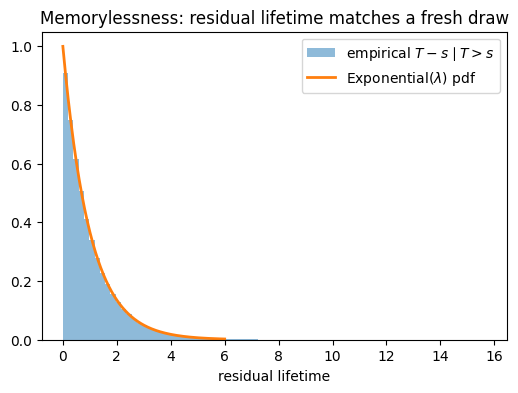

empirical mean residual lifetime: 0.9996  (theory: 1/lambda = 1.0000)


In [3]:
# numerical check of memorylessness
lam = 1.0
s = 1.5
N = 2_000_000
draws = rng.exponential(scale=1/lam, size=N)
survivors = draws[draws > s]
residual = survivors - s

tt = np.linspace(0, 6, 300)
plt.hist(residual, bins=80, density=True, alpha=0.5, label=r"empirical $T-s \mid T>s$")
plt.plot(tt, lam*np.exp(-lam*tt), color="C1", lw=2, label=r"Exponential$(\lambda)$ pdf")
plt.legend()
plt.xlabel("residual lifetime")
plt.title("Memorylessness: residual lifetime matches a fresh draw")
plt.show()

print(f"empirical mean residual lifetime: {residual.mean():.4f}  (theory: 1/lambda = {1/lam:.4f})")

---

### Law of Total Probability

Just as events can be decomposed over a partition, so can the PMF/PDF of a
random variable: if $A_1, \dots, A_n$ partition the sample space
($P(A_i) > 0$, $\sum_i P(A_i) = 1$), then

::: {.callout-note}
## Theorem: law of total probability, RV form

$$
p_X(x) = \sum_{i=1}^n P(A_i)\, p_{X \mid A_i}(x), \qquad
f_X(x) = \sum_{i=1}^n P(A_i)\, f_{X \mid A_i}(x).
$$
:::

. . .

#### Example: a mixture of two lifetimes

A factory's widgets come off one of two machines: Machine 1 (probability
$p$) produces lifetimes $T \sim \text{Exponential}(\lambda_1)$, Machine 2
(probability $1-p$) produces $T \sim \text{Exponential}(\lambda_2)$. A
widget is picked at random, without knowing which machine made it. Its
overall lifetime density is the **mixture**
$$
f_T(t) = p\,\lambda_1 e^{-\lambda_1 t} + (1-p)\,\lambda_2 e^{-\lambda_2 t}.
$$

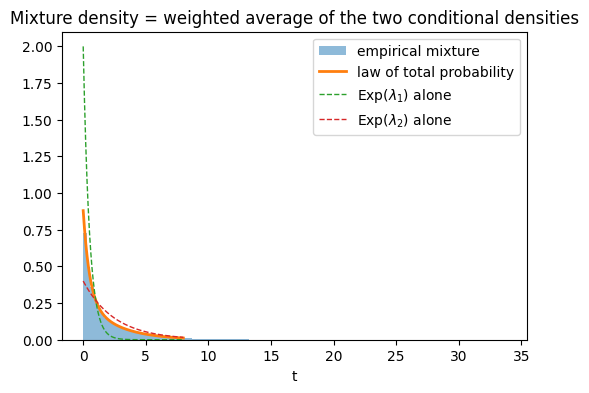

integral of mixture density: 1.0000  (should be 1)


In [4]:
# mixture-of-two-exponentials example
p, lam1, lam2 = 0.3, 2.0, 0.4

def f_mix(t):
    return p*lam1*np.exp(-lam1*t) + (1-p)*lam2*np.exp(-lam2*t)

N = 1_000_000
machine = rng.random(N) < p
T = np.where(machine, rng.exponential(1/lam1, N), rng.exponential(1/lam2, N))

tt = np.linspace(0, 8, 400)
plt.hist(T, bins=120, density=True, alpha=0.5, label="empirical mixture")
plt.plot(tt, f_mix(tt), color="C1", lw=2, label="law of total probability")
plt.plot(tt, lam1*np.exp(-lam1*tt), color="C2", lw=1, ls="--", label=r"$\mathrm{Exp}(\lambda_1)$ alone")
plt.plot(tt, lam2*np.exp(-lam2*tt), color="C3", lw=1, ls="--", label=r"$\mathrm{Exp}(\lambda_2)$ alone")
plt.legend()
plt.xlabel("t")
plt.title("Mixture density = weighted average of the two conditional densities")
plt.show()

check = integrate.quad(f_mix, 0, np.inf)[0]
print(f"integral of mixture density: {check:.4f}  (should be 1)")

## Conditioning One RV on Another

::: {.callout-note}
## Definition: conditional PDF given another RV

For jointly continuous $X, Y$ with $f_Y(y) > 0$,
$$
f_{X \mid Y}(x \mid y) \;=\; \frac{f_{X,Y}(x,y)}{f_Y(y)}.
$$
:::

. . .

This is the exact continuous analogue of L5's $p_{X\mid Y}(x\mid y) =
p_{X,Y}(x,y)/p_Y(y)$: for each fixed $y$, we take the *slice* of the joint
density along $Y=y$ and rescale it (divide by $f_Y(y)$) so it integrates to
$1$ in $x$.

---

### Example: Dartboard

Let $(X, Y)$ be uniform on the unit disk (a dart thrown uniformly at a
circular board of radius 1):
$$
f_{X,Y}(x,y) = \begin{cases} \dfrac{1}{\pi}, & x^2+y^2 \le 1,\\[2pt] 0, & \text{otherwise.}\end{cases}
$$

Recall from Lecture 7 that this has a *non-uniform* marginal,
$f_X(x) = \dfrac{2\sqrt{1-x^2}}{\pi}$ for $|x|\le 1$.

. . .

**Conditional PDF, circular uniform case.** For $|x| < 1$,
$$
f_{Y\mid X}(y \mid x) = \frac{f_{X,Y}(x,y)}{f_X(x)}
= \frac{1/\pi}{2\sqrt{1-x^2}/\pi}
= \frac{1}{2\sqrt{1-x^2}}, \qquad |y| < \sqrt{1-x^2}.
$$

::: {.callout-tip}
## Physical interpretation

Given only the dart's horizontal coordinate $X=x$, the possible vertical
landing spots are the **chord** of the disk at that $x$ -- and $Y$ is
*uniform* over that chord, even though the joint density was uniform over
the whole disk. Conditioning "slices" the flat joint density and renormalizes
the slice; the slice itself is still flat, so it's uniform on its (shorter)
interval.
:::

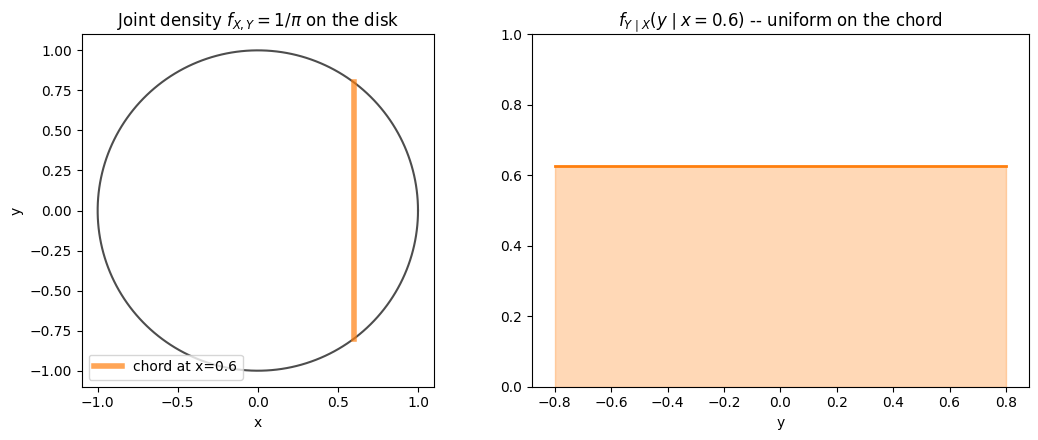

empirical mean of Y | X~0.6: 0.0003  (theory: 0, by symmetry)
empirical range roughly [-0.813, 0.814]  (theory: [-0.800, 0.800])


In [5]:
# dartboard: joint density on the disk, and a conditional slice
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

theta = np.linspace(0, 2*np.pi, 200)
axes[0].plot(np.cos(theta), np.sin(theta), color="0.3")
axes[0].set_aspect("equal")
x0 = 0.6
ylim = np.sqrt(1 - x0**2)
axes[0].plot([x0, x0], [-ylim, ylim], color="C1", lw=4, alpha=0.7,
             label=f"chord at x={x0}")
axes[0].set_title(r"Joint density $f_{X,Y}=1/\pi$ on the disk")
axes[0].legend(loc="lower left")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")

yy = np.linspace(-ylim, ylim, 200)
f_cond = np.full_like(yy, 1/(2*ylim))
axes[1].plot(yy, f_cond, color="C1", lw=2)
axes[1].fill_between(yy, f_cond, alpha=0.3, color="C1")
axes[1].set_ylim(0, 1)
axes[1].set_title(r"$f_{Y\mid X}(y \mid x=0.6)$ -- uniform on the chord")
axes[1].set_xlabel("y")

plt.tight_layout()
plt.show()

# Monte Carlo check: simulate uniform points on the disk, look at Y near X=0.6
N = 4_000_000
pts = rng.uniform(-1, 1, size=(N, 2))
inside = pts[:, 0]**2 + pts[:, 1]**2 <= 1
pts = pts[inside]
near = pts[np.abs(pts[:, 0] - x0) < 0.02]
print(f"empirical mean of Y | X~{x0}: {near[:,1].mean():.4f}  (theory: 0, by symmetry)")
print(f"empirical range roughly [{near[:,1].min():.3f}, {near[:,1].max():.3f}]  (theory: [-{ylim:.3f}, {ylim:.3f}])")

## Conditional Expectation

::: {.callout-note}
## Definition

$$
E[X \mid A] = \sum_x x\, p_{X\mid A}(x) \quad\text{or}\quad \int x\, f_{X\mid A}(x)\,dx,
$$
$$
E[X \mid Y=y] = \sum_x x\, p_{X\mid Y}(x\mid y) \quad\text{or}\quad \int x\, f_{X\mid Y}(x\mid y)\,dx.
$$
:::

. . .

::: {.callout-tip}
## LOTUS still holds

$$
E[g(X) \mid Y=y] = \sum_x g(x)\, p_{X\mid Y}(x\mid y) \quad\text{or}\quad \int g(x)\, f_{X\mid Y}(x\mid y)\,dx.
$$
Conditioning just replaces the unconditional (marginal) distribution with the
conditional one everywhere in the LOTUS formula.
:::

. . .

::: {.callout-note}
## Theorem: total expectation theorem

Partition form: $\;E[X] = \sum_i P(A_i)\, E[X \mid A_i]$.

RV form: $\;E[X] = E\big[E[X \mid Y]\big] = \displaystyle\int E[X\mid Y=y]\, f_Y(y)\, dy$.
:::

---

### Example: Dartboard, continued

::: {.callout-warning}
## A note on this slide

Jamie's outline left this example as "Example: ?" -- open. The dartboard
setup from the previous section gives a clean, self-contained continuation,
so it's used here; swap in a different example if you'd prefer something new.
:::

By the symmetry $f_{Y\mid X}(y\mid x) = f_{Y\mid X}(-y\mid x)$ established
above,
$$
E[Y \mid X=x] = \int_{-\sqrt{1-x^2}}^{\sqrt{1-x^2}} y \cdot \frac{1}{2\sqrt{1-x^2}}\, dy = 0 \quad \text{for every } x.
$$

. . .

By the total expectation theorem (RV form),
$$
E[Y] = E\big[E[Y\mid X]\big] = \int_{-1}^1 0 \cdot f_X(x)\,dx = 0,
$$
consistent with computing $E[Y]$ directly from the (also symmetric) marginal
$f_Y$.

In [6]:
# check E[Y|X=x] = 0 for several x, and the tower property E[Y] = E[E[Y|X]]
xs = np.linspace(-0.9, 0.9, 7)
for x0 in xs:
    ylim = np.sqrt(1 - x0**2)
    EY_given_x = integrate.quad(lambda y: y/(2*ylim), -ylim, ylim)[0]
    print(f"x = {x0:+.2f}:  E[Y|X=x] = {EY_given_x:+.6f}")

# tower property, numerically, via the marginal of X
EY_tower = integrate.quad(lambda x: 0.0 * (2*np.sqrt(1-x**2)/np.pi), -1, 1)[0]
print(f"\nE[Y] via tower property = {EY_tower:.6f}")

N = 3_000_000
pts = rng.uniform(-1, 1, size=(N, 2))
pts = pts[pts[:,0]**2 + pts[:,1]**2 <= 1]
print(f"E[Y] via direct simulation = {pts[:,1].mean():.6f}")

x = -0.90:  E[Y|X=x] = +0.000000
x = -0.60:  E[Y|X=x] = +0.000000
x = -0.30:  E[Y|X=x] = +0.000000
x = -0.00:  E[Y|X=x] = +0.000000
x = +0.30:  E[Y|X=x] = +0.000000
x = +0.60:  E[Y|X=x] = +0.000000
x = +0.90:  E[Y|X=x] = +0.000000

E[Y] via tower property = 0.000000
E[Y] via direct simulation = -0.000221


## Independence

::: {.callout-note}
## Definition

Continuous $X, Y$ are **independent** if
$$
f_{X,Y}(x,y) = f_X(x)\, f_Y(y) \quad \text{for all } x, y,
$$
equivalently $f_{X\mid Y}(x\mid y) = f_X(x)$ whenever $f_Y(y) > 0$.
:::

. . .

::: {.callout-tip}
## Two facts carried over from L5 (discrete case)

**Product rule for expectation.** If $X, Y$ independent, $E[XY] = E[X]\,E[Y]$
(the joint density factors, so the double integral in two-variable LOTUS
splits into a product of two single integrals).

**Linearity of variance.** If $X, Y$ independent,
$\mathrm{Var}(X+Y) = \mathrm{Var}(X) + \mathrm{Var}(Y)$ (the covariance
cross-term vanishes). Unlike linearity of *expectation*, this genuinely
needs independence.
:::

---

### Example: Joint PDF of Independent Gaussian RVs

If $X_1, \dots, X_n$ are independent with $X_i \sim N(\mu_i, \sigma_i^2)$,
their joint density is simply the product of the marginals:
$$
f(x_1,\dots,x_n) = \prod_{i=1}^n \frac{1}{\sqrt{2\pi}\sigma_i} \exp\!\left(-\frac{(x_i-\mu_i)^2}{2\sigma_i^2}\right).
$$

. . .

::: {.callout-note}
## Covariance matrix

Writing $\mathbf{X} = (X_1,\dots,X_n)$, the covariance matrix
$\Sigma_{ij} = \mathrm{Cov}(X_i, X_j)$ collects all pairwise covariances.
Independence forces every off-diagonal entry to $0$, so
$$
\Sigma = \mathrm{diag}(\sigma_1^2, \dots, \sigma_n^2),
$$
and the joint density above can be written compactly as
$$
f(\mathbf{x}) = \frac{1}{(2\pi)^{n/2} |\Sigma|^{1/2}} \exp\!\left(-\tfrac{1}{2}(\mathbf{x}-\boldsymbol\mu)^\top \Sigma^{-1} (\mathbf{x}-\boldsymbol\mu)\right).
$$
This is the general multivariate normal density -- L7 previewed
$\mathbf{X}\sim N(\boldsymbol\mu,\Sigma)$ via "every linear combination is
normal"; here we see the density explicitly for the independent case.
:::

. . .

::: {.callout-note}
## Definition: isotropic

If, further, every $\sigma_i = \sigma$, then $\Sigma = \sigma^2 I$ and $f$
depends on $\mathbf x$ only through $\|\mathbf x - \boldsymbol\mu\|^2$ --
the density looks the **same in every direction**. Such a distribution is
called **isotropic**. Its level sets (contours of equal density) are circles
(or spheres, in higher dimension) rather than general ellipses.
:::

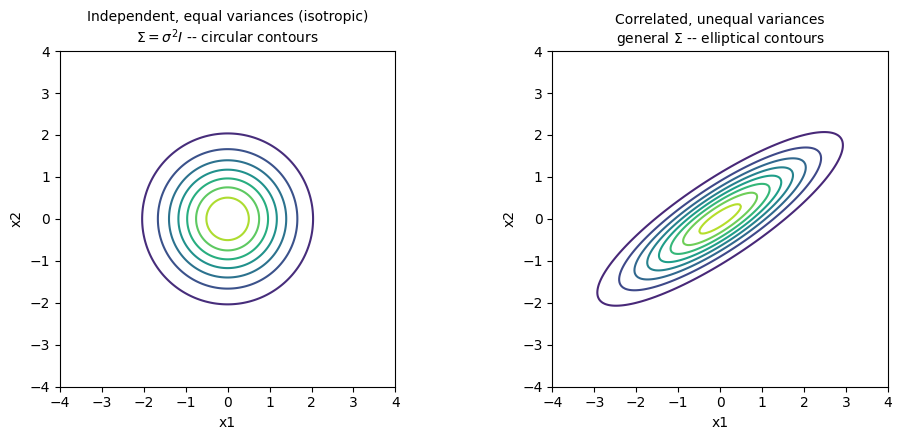

Sigma (isotropic case): [[1. 0.]
 [0. 1.]]
Sigma (general case):   [[2.  1.2]
 [1.2 1. ]]


In [7]:
# independent isotropic Gaussian (circular contours) vs. a general
# (correlated / non-isotropic) Gaussian (elliptical contours) -- L7 teaser, resolved
from scipy.stats import multivariate_normal

x = np.linspace(-4, 4, 200)
y = np.linspace(-4, 4, 200)
X, Y = np.meshgrid(x, y)
pos = np.dstack((X, Y))

mu = [0, 0]
Sigma_isotropic = [[1.0, 0.0], [0.0, 1.0]]          # sigma^2 I
Sigma_general    = [[2.0, 1.2], [1.2, 1.0]]          # correlated, non-isotropic

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, Sigma, title in zip(
    axes, [Sigma_isotropic, Sigma_general],
    ["Independent, equal variances (isotropic)\n" + r"$\Sigma=\sigma^2 I$ -- circular contours",
     "Correlated, unequal variances\n" + r"general $\Sigma$ -- elliptical contours"]):
    rv = multivariate_normal(mu, Sigma)
    ax.contour(X, Y, rv.pdf(pos), levels=8, cmap="viridis")
    ax.set_aspect("equal")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("x1"); ax.set_ylabel("x2")

plt.tight_layout()
plt.show()

print("Sigma (isotropic case):", np.array(Sigma_isotropic))
print("Sigma (general case):  ", np.array(Sigma_general))

# Bayes' Rule

## Inference

**The idea.** We have some unknown quantity $\Theta$ (a parameter, a
hypothesis, a signal -- anything unobserved) and a **prior** distribution
for it that reflects our belief before seeing any data. We then observe data
$X$, whose distribution depends on $\Theta$. Bayes' rule turns this around:
it produces the **posterior** distribution of $\Theta$ given the data we
actually observed.

. . .

$$
\underbrace{f_\Theta(\theta)}_{\text{prior}} \quad\Longrightarrow\quad \text{observe } X=x \quad\Longrightarrow\quad \underbrace{f_{\Theta\mid X}(\theta \mid x)}_{\text{posterior}}
$$

. . .

$\Theta$ and $X$ can each be discrete or continuous, giving four cases. Today
we'll work through the continuous-continuous case here, then the two mixed
cases in the next two sections.

---

### Example: Lightbulb w/ Exponential Lifetime (estimating mean parameter)

An engineer doesn't know a bulb's failure rate $\lambda$ exactly, but
believes it's somewhere between $0.5$ and $2.0$ (per year), with no value
more likely than another *a priori*:
$$
\Lambda \sim \text{Uniform}(0.5,\, 2.0).
$$
She observes one bulb's lifetime $X = x$, where $X \mid \Lambda=\lambda \sim \text{Exponential}(\lambda)$.

. . .

::: {.callout-note}
## Bayes' rule, continuous-continuous case

$$
f_{\Lambda \mid X}(\lambda \mid x) = \frac{f_{X\mid\Lambda}(x\mid\lambda)\, f_\Lambda(\lambda)}{f_X(x)},
\qquad
f_X(x) = \int f_{X\mid\Lambda}(x\mid\lambda)\, f_\Lambda(\lambda)\, d\lambda.
$$
:::

This is exactly the definition of a conditional PDF from earlier in the
lecture, just applied with $\Theta=\Lambda$ playing the role of $Y$ and $X$
playing the role of $X$ -- Bayes' rule for continuous random variables adds
nothing new beyond relabeling.

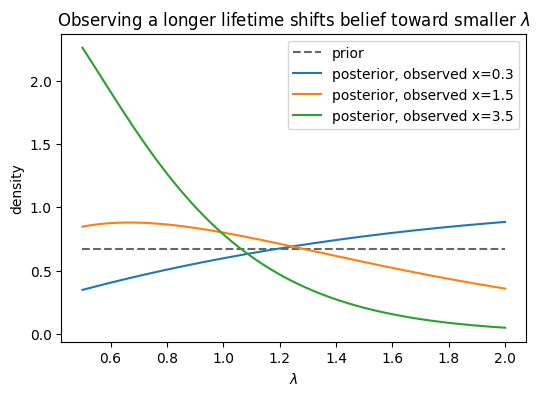

x=0.3: f_X(x)=0.8275, posterior integrates to 1.0000
x=1.5: f_X(x)=0.1859, posterior integrates to 1.0000
x=3.5: f_X(x)=0.0256, posterior integrates to 1.0000


In [8]:
# lightbulb: continuous prior, continuous observation
a, b = 0.5, 2.0  # prior support

def prior(lam):
    return np.where((lam >= a) & (lam <= b), 1.0/(b-a), 0.0)

def likelihood(x, lam):
    return lam * np.exp(-lam * x)

def evidence(x):
    return integrate.quad(lambda lam: likelihood(x, lam) * prior(lam), a, b)[0]

def posterior(lam, x):
    return likelihood(x, lam) * prior(lam) / evidence(x)

lams = np.linspace(a, b, 300)

fig, ax = plt.subplots()
ax.plot(lams, prior(lams), color="0.4", ls="--", label="prior")
for x_obs, color in zip([0.3, 1.5, 3.5], ["C0", "C1", "C2"]):
    post = [posterior(l, x_obs) for l in lams]
    ax.plot(lams, post, color=color, label=f"posterior, observed x={x_obs}")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("density")
ax.legend()
ax.set_title("Observing a longer lifetime shifts belief toward smaller " + r"$\lambda$")
plt.show()

for x_obs in [0.3, 1.5, 3.5]:
    ev = evidence(x_obs)
    check = integrate.quad(lambda l: posterior(l, x_obs), a, b)[0]
    print(f"x={x_obs}: f_X(x)={ev:.4f}, posterior integrates to {check:.4f}")

## Inference about Discrete RV

Now suppose $\Theta$ is **discrete** but the data $X$ we observe is
**continuous** -- e.g. a discrete hypothesis observed through noisy,
continuous measurements.

. . .

::: {.callout-note}
## Derivation

Start from the definition of a conditional PDF given an event, applied to
$A = \{\Theta = \theta\}$, together with the (RV form) law of total
probability for $f_X$:
$$
P(\Theta=\theta \mid X=x) = \frac{f_{X\mid\Theta}(x\mid\theta)\, P(\Theta=\theta)}{f_X(x)},
\qquad
f_X(x) = \sum_\theta f_{X\mid\Theta}(x\mid\theta)\, P(\Theta=\theta).
$$
:::

The denominator is exactly the Law of Total Probability from earlier in the
lecture, now applied with the partition $\{\Theta=\theta\}$ over all possible
values of $\theta$.

---

### Example: Signal Detection

Recall Lecture 7's signal-detection setup: a binary signal
$S\in\{-1,+1\}$ is sent with equal prior probability, through a channel
with additive noise $N \sim N(0,\sigma^2)$ independent of $S$, so we
observe $Y = S + N$. L7 derived the *error probability* of the rule "decide
$+1$ if $Y>0$"; today we derive that rule itself, as a consequence of Bayes'
rule.

. . .

By the formula above (with $\Theta = S$, discrete; $X = Y$, continuous):
$$
P(S=+1 \mid Y=y) = \frac{\phi\!\left(\frac{y-1}{\sigma}\right) \cdot \tfrac12}
{\phi\!\left(\frac{y-1}{\sigma}\right)\tfrac12 + \phi\!\left(\frac{y+1}{\sigma}\right)\tfrac12}
= \frac{1}{1 + e^{-2y/\sigma^2}},
$$
where $\phi$ is the standard normal density (the $\tfrac12$ prior factors
cancel, and the Gaussian exponents simplify to the logistic form on the
right).

. . .

::: {.callout-tip}
## Recovering the decision rule

$P(S=+1\mid Y=y) > \tfrac12$ exactly when $y > 0$. So "declare $+1$ when
$Y>0$" -- the rule L7 just posited -- is precisely the rule that picks the
**more probable** signal given the observation (the MAP, or maximum a
posteriori, rule) when the two signals are equally likely a priori.
:::

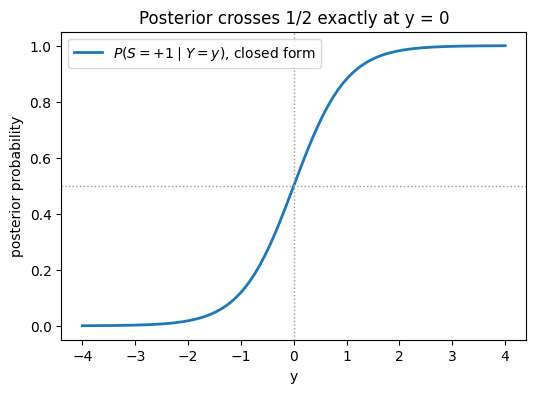

y~-2.0: empirical P(S=+1|Y~y) = 0.0183   formula = 0.0180
y~-1.0: empirical P(S=+1|Y~y) = 0.1190   formula = 0.1192
y~-0.3: empirical P(S=+1|Y~y) = 0.3539   formula = 0.3543
y~+0.3: empirical P(S=+1|Y~y) = 0.6491   formula = 0.6457
y~+1.0: empirical P(S=+1|Y~y) = 0.8795   formula = 0.8808
y~+2.0: empirical P(S=+1|Y~y) = 0.9821   formula = 0.9820


In [9]:
# signal detection: posterior P(S=+1 | Y=y), derived vs. simulated
sigma = 1.0

def posterior_plus(y, sigma=sigma):
    return 1.0 / (1.0 + np.exp(-2*y/sigma**2))

yy = np.linspace(-4, 4, 300)
fig, ax = plt.subplots()
ax.plot(yy, posterior_plus(yy), color="C0", lw=2, label=r"$P(S=+1\mid Y=y)$, closed form")
ax.axhline(0.5, color="0.6", lw=1, ls=":")
ax.axvline(0, color="0.6", lw=1, ls=":")
ax.set_xlabel("y"); ax.set_ylabel("posterior probability")
ax.legend()
ax.set_title("Posterior crosses 1/2 exactly at y = 0")
plt.show()

# Monte Carlo check: bucket simulated y's and compare empirical P(S=+1|Y~y) to formula
N = 4_000_000
S = rng.choice([-1, 1], size=N)
Y = S + rng.normal(0, sigma, size=N)

test_ys = [-2.0, -1.0, -0.3, 0.3, 1.0, 2.0]
width = 0.05
for y0 in test_ys:
    bucket = (Y > y0 - width) & (Y < y0 + width)
    emp = (S[bucket] == 1).mean()
    print(f"y~{y0:+.1f}: empirical P(S=+1|Y~y) = {emp:.4f}   formula = {posterior_plus(y0):.4f}")

## Inference Based on Discrete Observations

Symmetrically: now $\Theta$ may be **continuous** while the data $N$ we
observe is **discrete** (a count, say).

. . .

::: {.callout-note}
## Bayes' rule, continuous $\Theta$ / discrete $N$

$$
f_{\Theta \mid N}(\theta \mid n) = \frac{P(N=n\mid\Theta=\theta)\, f_\Theta(\theta)}{P(N=n)},
\qquad
P(N=n) = \int P(N=n\mid\Theta=\theta)\, f_\Theta(\theta)\, d\theta.
$$
:::

Same structure as before, with the roles of "discrete" and "continuous"
swapped between $\Theta$ and the observation.

---

### Example: Estimating a Coin's Bias

::: {.callout-warning}
## A note on this slide

Jamie's outline marked this example "??" -- fully open. The classic
coin-bias / polling problem is a natural way to close the lecture, since it's
the continuous-$\Theta$, discrete-observation case and reinforces "more data
$\Rightarrow$ sharper posterior." Swap in a different example if you'd
prefer.
:::

A coin's probability of heads $\Theta$ is unknown; take a totally
uninformative prior $\Theta \sim \text{Uniform}(0,1)$. Flip it $n$ times and
observe $N$ = number of heads, where $N\mid\Theta=\theta \sim
\text{Binomial}(n,\theta)$.

. . .

$$
f_{\Theta\mid N}(\theta \mid k) \;\propto\; \binom{n}{k}\theta^k(1-\theta)^{n-k} \cdot 1
\;\propto\; \theta^k (1-\theta)^{n-k}, \qquad 0 \le \theta \le 1,
$$
normalized by dividing by $\displaystyle\int_0^1 \theta^k(1-\theta)^{n-k}\,d\theta$.

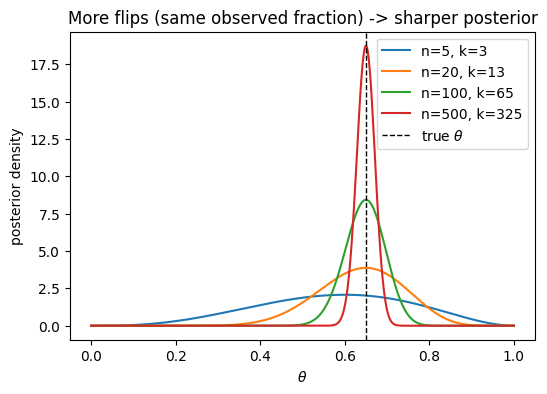

n=   5, k=   3:  posterior mean = 0.5714  (observed k/n = 0.6000)
n=  20, k=  13:  posterior mean = 0.6364  (observed k/n = 0.6500)
n= 100, k=  65:  posterior mean = 0.6471  (observed k/n = 0.6500)
n= 500, k= 325:  posterior mean = 0.6493  (observed k/n = 0.6500)


In [10]:
# coin-bias inference: posterior concentrates as n grows (same observed proportion)
theta_true = 0.65
theta_grid = np.linspace(0, 1, 400)

def unnorm_posterior(theta, n, k):
    return theta**k * (1-theta)**(n-k)

fig, ax = plt.subplots()
for n in [5, 20, 100, 500]:
    k = int(round(theta_true * n))  # keep the observed proportion k/n ~ theta_true
    up = unnorm_posterior(theta_grid, n, k)
    Z = integrate.quad(lambda t: unnorm_posterior(t, n, k), 0, 1)[0]
    ax.plot(theta_grid, up/Z, label=f"n={n}, k={k}")

ax.axvline(theta_true, color="k", lw=1, ls="--", label=r"true $\theta$")
ax.set_xlabel(r"$\theta$"); ax.set_ylabel("posterior density")
ax.legend()
ax.set_title("More flips (same observed fraction) -> sharper posterior")
plt.show()

# sanity check: posterior mean should approach k/n = theta_true as n grows
for n in [5, 20, 100, 500]:
    k = int(round(theta_true * n))
    Z = integrate.quad(lambda t: unnorm_posterior(t, n, k), 0, 1)[0]
    mean = integrate.quad(lambda t: t*unnorm_posterior(t, n, k), 0, 1)[0] / Z
    print(f"n={n:4d}, k={k:4d}:  posterior mean = {mean:.4f}  (observed k/n = {k/n:.4f})")